In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

from src.data_loader import load_week1_outputs
from src.allocation_baseline import get_outstanding_shares
from src.backtest_engine import run_backtest, compute_weights_at_date, get_estimation_data

In [3]:
# Reload all output from Week 1
data = load_week1_outputs()
prices_pivot = data['prices_pivot']
log_returns = data['log_returns']
pit_membership = data['pit_membership']
vn30_index = data['vn30_index']

In [4]:
full_universe = sorted(set().union(*pit_membership.values()))
outstanding_shares = get_outstanding_shares(full_universe)

rebalance_dates = pd.date_range(start='2021-01-01', end='2026-07-01', freq='QS')

results = run_backtest(rebalance_dates, prices_pivot, pit_membership, outstanding_shares, vn30_index)
print(results)

Error fetching outstanding shares for ROS: 'outstanding_shares'
Processing 2021-01-01...
Processing 2021-04-01...
Processing 2021-07-01...
Processing 2021-10-01...
Processing 2022-01-01...
Processing 2022-04-01...
Processing 2022-07-01...
Processing 2022-10-01...
Processing 2023-01-01...
Processing 2023-04-01...
Processing 2023-07-01...
Processing 2023-10-01...
Processing 2024-01-01...
Processing 2024-04-01...
Processing 2024-07-01...
Processing 2024-10-01...
Processing 2025-01-01...
Processing 2025-04-01...
Processing 2025-07-01...
Processing 2025-10-01...
Processing 2026-01-01...
Processing 2026-04-01...
               equal  market_cap  markowitz  black_litterman
2021-01-01  1.000000    1.000000   1.000000         1.000000
2021-04-01  1.070855    1.048600   1.104460         1.026363
2021-07-01  1.300033    1.250661   1.773261         1.354534
2021-10-01  1.260327    1.152642   1.558993         1.218009
2022-01-01  1.386344    1.237175   1.665121         1.329678
2022-04-01  1.367133

In [5]:
# Check for suspiciously large single-period jumps — could signal a bug
returns_per_period = results.pct_change()
print(returns_per_period.describe())
print(returns_per_period[returns_per_period.abs() > 0.3].dropna(how='all'))

           equal  market_cap  markowitz  black_litterman
count  22.000000   22.000000  22.000000        22.000000
mean    0.028294    0.028874   0.052806         0.050284
std     0.092261    0.102580   0.241795         0.151777
min    -0.183179   -0.172072  -0.505316        -0.155557
25%    -0.028277   -0.039234  -0.083911        -0.036222
50%     0.037472    0.028514   0.027133         0.014115
75%     0.055321    0.070836   0.137769         0.082036
max     0.229896    0.244458   0.605546         0.374842
            equal  market_cap  markowitz  black_litterman
2021-07-01    NaN         NaN   0.605546         0.319742
2023-01-01    NaN         NaN  -0.505316              NaN
2025-10-01    NaN         NaN   0.445751         0.342439
2026-01-01    NaN         NaN        NaN         0.374842
2026-07-01    NaN         NaN   0.430373              NaN


In [7]:
def compute_drawdown_series(cumulative_series):
    """
    Drawdown at each point = % below the running historical peak
    0 means at a new all-time high; negative values show the depth of loss from the most recent peak
    """
    running_max = cumulative_series.cummax()
    return (cumulative_series - running_max) / running_max

drawdowns = results.apply(compute_drawdown_series)
print(drawdowns.describe())

           equal  market_cap  markowitz  black_litterman
count  23.000000   23.000000  23.000000        23.000000
mean   -0.105087   -0.133409  -0.382322        -0.125480
std     0.105100    0.111800   0.258417         0.100585
min    -0.298691   -0.304834  -0.686384        -0.274373
25%    -0.204517   -0.232823  -0.604847        -0.215618
50%    -0.083458   -0.150073  -0.386760        -0.122328
75%     0.000000   -0.005391  -0.138134        -0.009175
max     0.000000    0.000000   0.000000         0.000000


In [8]:
def compute_full_metrics(cumulative_series, drawdown_series, periods_per_year=4):
    returns = cumulative_series.pct_change().dropna()
    n_years = len(returns) / periods_per_year

    cagr = cumulative_series.iloc[-1] ** (1 / n_years) - 1
    vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = (returns.mean() * periods_per_year - 0.035) / vol
    max_dd = drawdown_series.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan  # return per unit of worst-case loss

    return {'CAGR': cagr, 'Volatility': vol, 'Sharpe': sharpe, 'Max Drawdown': max_dd, 'Calmar': calmar}

metrics_table = pd.DataFrame({
    strategy: compute_full_metrics(results[strategy], drawdowns[strategy])
    for strategy in results.columns
}).T
print(metrics_table.round(3))

                  CAGR  Volatility  Sharpe  Max Drawdown  Calmar
equal            0.101       0.185   0.424        -0.299   0.338
market_cap       0.100       0.205   0.392        -0.305   0.327
markowitz        0.103       0.484   0.364        -0.686   0.151
black_litterman  0.172       0.304   0.547        -0.274   0.627


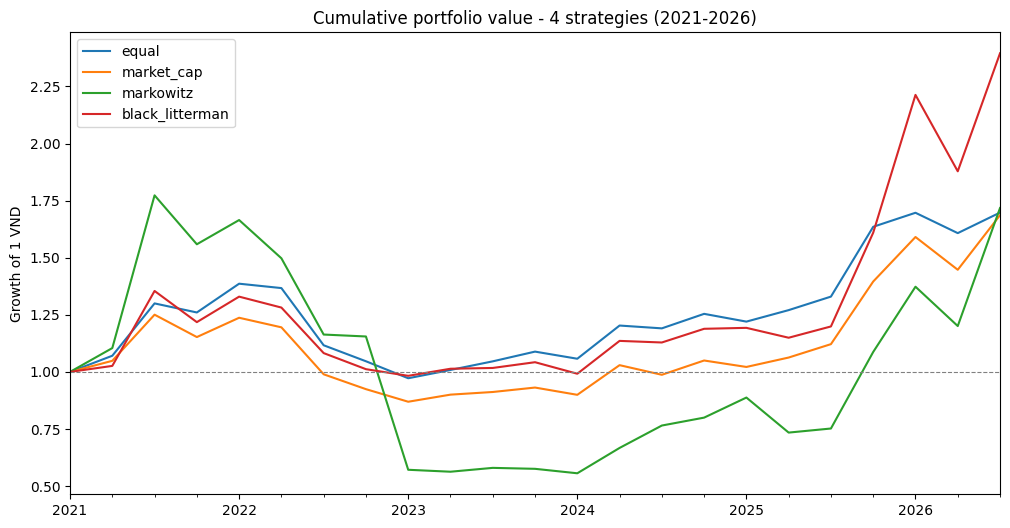

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
results.plot(ax=ax)
ax.set_title('Cumulative portfolio value - 4 strategies (2021-2026)')
ax.set_ylabel('Growth of 1 VND')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

In [10]:
results.to_csv('../data/processed/week4_backtest_results.csv')

In [11]:
def drawdown_summary(drawdowns):
    summary = {}
    for strategy in drawdowns.columns:
        dd = drawdowns[strategy]
        max_dd = dd.min()
        max_dd_date = dd.idxmin()

        # Recovery time: how long from the trough back to a new all-time high (or "not yet recovered"
        peak_before = dd[:max_dd_date][dd[:max_dd_date] == 0].index
        recovery_after = dd[max_dd_date:][dd[max_dd_date:] >= 0].index

        recovery_date = recovery_after[0] if len(recovery_after) > 0 else None

        summary[strategy] = {
            'Max Drawdown': max_dd,
            'Max DD Date': max_dd_date,
            'Recovery Date': recovery_date if recovery_date is not None else 'Not yet recovered'
        }
    return pd.DataFrame(summary).T

dd_summary = drawdown_summary(drawdowns)
print(dd_summary)

                Max Drawdown          Max DD Date        Recovery Date
equal              -0.298691  2023-01-01 00:00:00  2025-10-01 00:00:00
market_cap         -0.304834  2023-01-01 00:00:00  2025-10-01 00:00:00
markowitz          -0.686384  2024-01-01 00:00:00    Not yet recovered
black_litterman    -0.274373  2023-01-01 00:00:00  2025-10-01 00:00:00


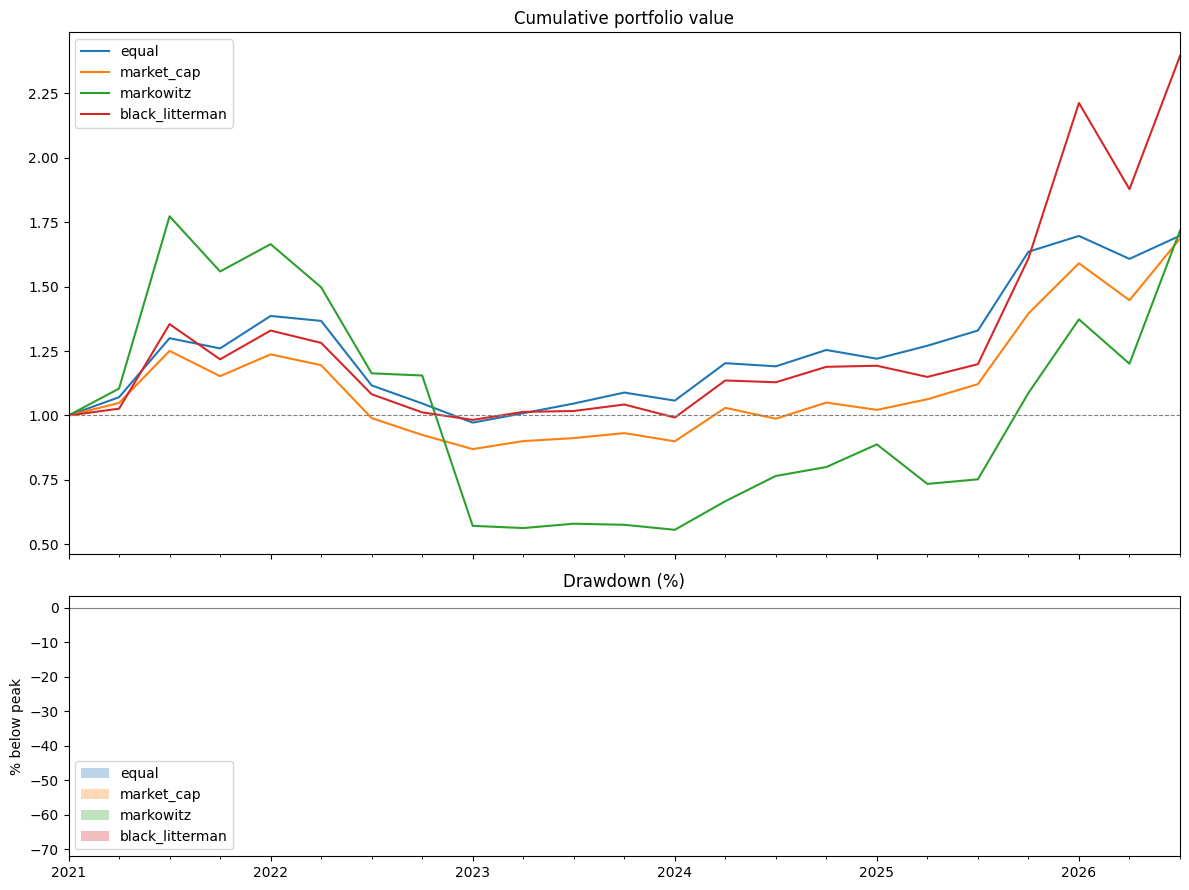

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Top: cumulative value (đã có từ trước)
results.plot(ax=axes[0])
axes[0].set_title('Cumulative portfolio value')
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

# Bottom: drawdown, filled area for clearer visual impact
for strategy in drawdowns.columns:
    axes[1].fill_between(drawdowns.index, drawdowns[strategy] * 100, 0, alpha=0.3, label=strategy)
    axes[1].plot(drawdowns.index, drawdowns[strategy] * 100, linewidth=1)

axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('% below peak')
axes[1].legend()
axes[1].axhline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.show()

In [13]:
metrics_table.to_csv('../data/processed/week4_metrics_summary.csv')
drawdowns.to_csv('../data/processed/week4_drawdowns.csv')
dd_summary.to_csv('../data/processed/week4_drawdown_summary.csv')

In [15]:
weights_at_crisis = compute_weights_at_date(
    pd.Timestamp('2024-01-01'), prices_pivot, pit_membership, outstanding_shares, vn30_index
)
print(weights_at_crisis['markowitz'].sort_values(ascending=False).head(10))

# Herfindahl index — đo mức độ tập trung (càng gần 1 càng tập trung cực đoan)
hhi = (weights_at_crisis['markowitz'] ** 2).sum()
print(f"Herfindahl concentration index: {hhi:.3f}")

FPT    0.842713
VCB    0.157287
MBB    0.000000
VIC    0.000000
VPB    0.000000
TPB    0.000000
ACB    0.000000
VHM    0.000000
GAS    0.000000
BID    0.000000
dtype: float64
Herfindahl concentration index: 0.735


In [17]:
view_history = {}
for rdate in rebalance_dates[:-1]:
    price_window, eligible = get_estimation_data(rdate, prices_pivot, pit_membership)
    if price_window is not None and len(eligible) >= 5:
        momentum = price_window.pct_change(252).iloc[-1].dropna()
        top5 = momentum.sort_values(ascending=False).head(5)
        view_history[rdate] = list(top5.index)

for date, tickers in view_history.items():
    print(date.date(), tickers)

2021-01-01 ['SSI', 'HPG', 'STB', 'CTG', 'VPB']
2021-04-01 ['HPG', 'SSI', 'PDR', 'STB', 'TCB']
2021-07-01 ['PDR', 'SSI', 'VPB', 'HPG', 'MBB']
2021-10-01 ['SSI', 'GVR', 'VPB', 'HPG', 'PDR']
2022-01-01 ['SSI', 'NVL', 'PDR', 'TPB', 'MSN']
2022-04-01 ['SSI', 'TPB', 'KDH', 'NVL', 'MWG']
2022-07-01 ['MWG', 'PNJ', 'MSN', 'FPT', 'GAS']
2022-10-01 ['SAB', 'GAS', 'NVL', 'POW', 'BID']
2023-01-01 ['SAB', 'BID', 'GAS', 'VCB', 'FPT']
2023-04-01 ['SAB', 'BCM', 'VCB', 'BID', 'VNM']
2023-07-01 ['SSI', 'STB', 'VCB', 'BID', 'BCM']
2023-10-01 ['SSI', 'STB', 'VCB', 'FPT', 'BID']
2024-01-01 ['SSI', 'HPG', 'GVR', 'HDB', 'FPT']
2024-04-01 ['GVR', 'SSI', 'FPT', 'TCB', 'MBB']
2024-07-01 ['FPT', 'GVR', 'TCB', 'MWG', 'HDB']
2024-10-01 ['GVR', 'HDB', 'FPT', 'TCB', 'MBB']
2025-01-01 ['FPT', 'HDB', 'TCB', 'GVR', 'MWG']
2025-04-01 ['LPB', 'BVH', 'SHB', 'STB', 'TCB']
2025-07-01 ['VIC', 'VHM', 'STB', 'LPB', 'TCB']
2025-10-01 ['VIC', 'VHM', 'SHB', 'LPB', 'STB']
2026-01-01 ['VIC', 'VHM', 'SHB', 'VJC', 'VRE']
2026-04-01 ['

In [19]:
weights_bl_at_crisis = weights_at_crisis['black_litterman']
print(weights_bl_at_crisis.sort_values(ascending=False).head(10))

hhi_bl = (weights_bl_at_crisis ** 2).sum()
print(f"Herfindahl concentration index (BL): {hhi_bl:.3f}")

VCB    0.138931
FPT    0.108296
BID    0.080635
HDB    0.058522
VIC    0.052125
VHM    0.049207
SSI    0.048192
CTG    0.047148
GAS    0.046859
VPB    0.043461
dtype: float64
Herfindahl concentration index (BL): 0.062


<Axes: title={'center': 'Portfolio concentration (Herfindahl index) over time'}>

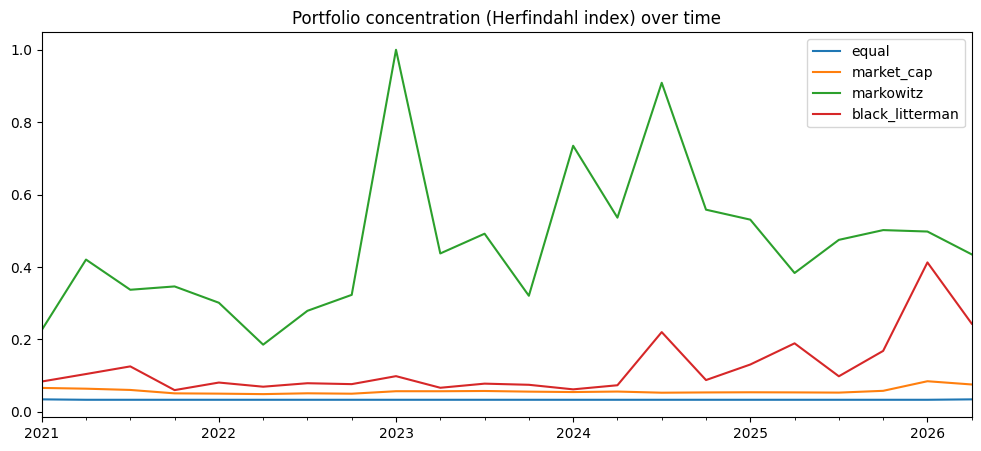

In [20]:
hhi_over_time = {s: [] for s in ['equal', 'market_cap', 'markowitz', 'black_litterman']}
valid_dates = []

for rdate in rebalance_dates[:-1]:
    w = compute_weights_at_date(rdate, prices_pivot, pit_membership, outstanding_shares, vn30_index)
    if w is None:
        continue
    valid_dates.append(rdate)
    for s in hhi_over_time:
        hhi_over_time[s].append((w[s] ** 2).sum())

hhi_df = pd.DataFrame(hhi_over_time, index=valid_dates)
hhi_df.plot(figsize=(12, 5), title='Portfolio concentration (Herfindahl index) over time')

In [22]:
fig = plt.gcf()
fig.savefig('../outputs/week4_hhi_over_time.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [23]:
hhi_df.to_csv('../data/processed/week4_hhi_over_time.csv')

In [24]:
print(hhi_df.describe())
print("\nMarkowitz HHI > 0.5 (severe concentration) tại bao nhiêu %/23 kỳ:")
print((hhi_df['markowitz'] > 0.5).mean() * 100, "%")

           equal  market_cap  markowitz  black_litterman
count  22.000000   22.000000  22.000000        22.000000
mean    0.033438    0.057537   0.465084         0.121996
std     0.000338    0.008562   0.201870         0.083144
min     0.033333    0.048974   0.185582         0.060038
25%     0.033333    0.052936   0.326631         0.075180
50%     0.033333    0.055251   0.436203         0.085763
75%     0.033333    0.057944   0.523620         0.129442
max     0.034483    0.084548   1.000000         0.412719

Markowitz HHI > 0.5 (severe concentration) tại bao nhiêu %/23 kỳ:
31.818181818181817 %
